CS 179 PROJECT!!!!

In [143]:
import sys
!{sys.executable} -m pip install yfinance
!{sys.executable} -m pip install hmmlearn

import yfinance as yf
import numpy as np
import pandas as pd
from hmmlearn import hmm
import matplotlib.pyplot as plt

ACTIVATE THE DATA

In [144]:
# load in data and calculate log returns
data = yf.download("SPY", start="2015-01-01", end="2024-12-31")
close_column = data["Close"].squeeze()
log_returns = {}

for index, (date, price) in enumerate(close_column.items()):
    if (index != 0):
        yesterday = close_column.shift(1)[date]
        log = np.log(price / yesterday)
        print(f"Log of date {date}: {log}")
        log_returns[date] = log
log_returns = pd.Series(log_returns)

[*********************100%***********************]  1 of 1 completed

Log of date 2015-01-05 00:00:00: -0.018225018145410346
Log of date 2015-01-06 00:00:00: -0.009463472685247765
Log of date 2015-01-07 00:00:00: 0.012384405908326615
Log of date 2015-01-08 00:00:00: 0.01758941522536229
Log of date 2015-01-09 00:00:00: -0.008045831530400397
Log of date 2015-01-12 00:00:00: -0.007864845091603683
Log of date 2015-01-13 00:00:00: -0.002816363637885157
Log of date 2015-01-14 00:00:00: -0.006055866435652933
Log of date 2015-01-15 00:00:00: -0.009202420555654197
Log of date 2015-01-16 00:00:00: 0.013029042781290445
Log of date 2015-01-20 00:00:00: 0.00213021945785084
Log of date 2015-01-21 00:00:00: 0.005035170208501654
Log of date 2015-01-22 00:00:00: 0.014761624644866517
Log of date 2015-01-23 00:00:00: -0.005497812102078158
Log of date 2015-01-26 00:00:00: 0.002338793587234155
Log of date 2015-01-27 00:00:00: -0.01327805960870513
Log of date 2015-01-28 00:00:00: -0.012907439046309505
Log of date 2015-01-29 00:00:00: 0.009201423318550856
Log of date 2015-01-3

SET TEST/TRAINING SPLITS

In [145]:
# 1 test set from Jan 2024 - Dec 2024
test_set = log_returns["2024-01-01":"2024-12-31"]

# 5 training sets of varying length
train_sets = [
    log_returns["2023-01-01":"2023-12-31"],
    log_returns["2022-01-01":"2023-12-31"],
    log_returns["2021-01-01":"2023-12-31"],
    log_returns["2020-01-01":"2023-12-31"],
    log_returns["2019-01-01":"2023-12-31"]
]

PLOT DATA

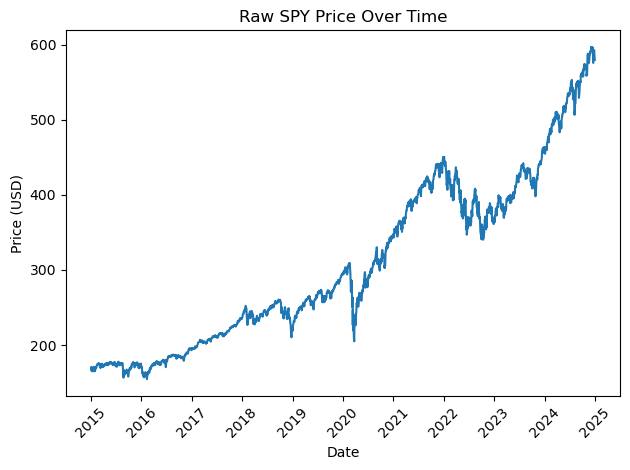

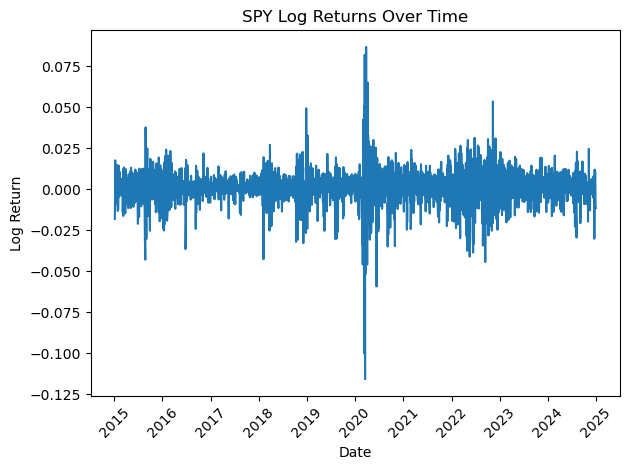

In [146]:
# raw SPY price over time
plt.plot(close_column)
plt.title("Raw SPY Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# log returns
plt.plot(log_returns)
plt.title("SPY Log Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

DATA SHAPE AND MODEL SETUP

In [147]:
# Gaussian baseline model built
hmm_model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=10000)

FIT ON TRAINING SET

In [148]:
# model trained on largest training set
train_set_reshape = train_sets[4].dropna().values.reshape(-1, 1)
trained_model = hmm_model.fit(train_set_reshape)

Model is not converging.  Current: 3913.306550194193 is not greater than 3913.622848886096. Delta is -0.31629869190328463


SCORE AND VISUALIZE TEST SET

In [149]:
# test set score
test_set_reshape = test_set.values.reshape(-1, 1)
test_set_score = trained_model.score(test_set_reshape)
print(test_set_score)

845.0564171460779


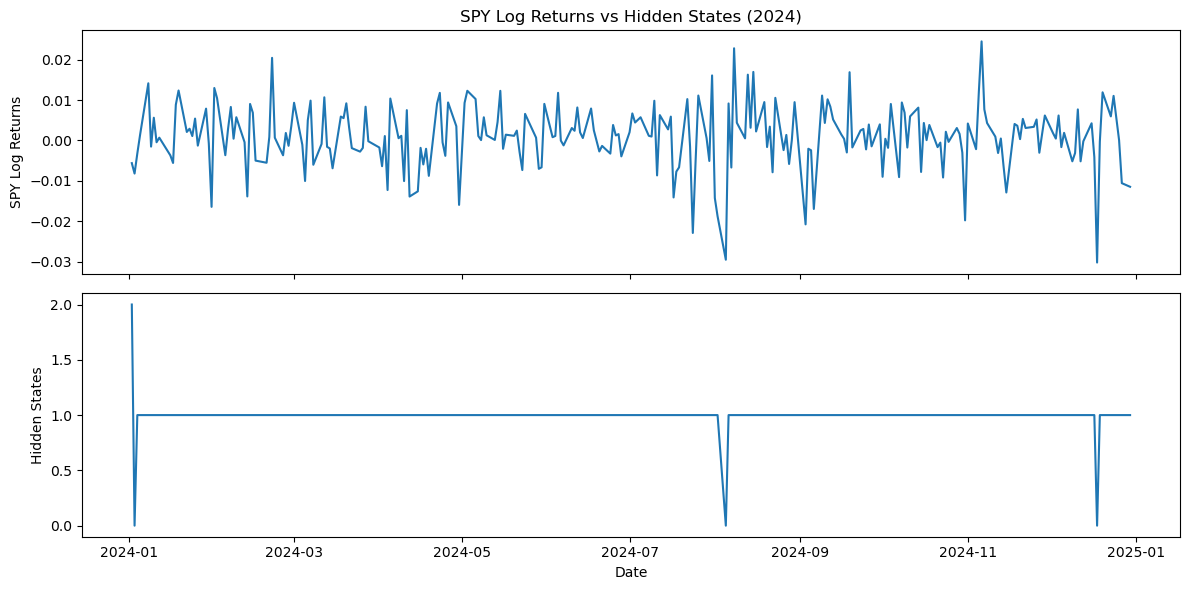

In [150]:
# hidden states from test set are plotted against SPY Prices
test_set_hidden = trained_model.predict(test_set_reshape)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(12, 6))

# SPY plot
ax1.plot(test_set.index, test_set.values)
ax1.set_ylabel("SPY Log Returns")
ax1.set_title("SPY Log Returns vs Hidden States (2024)")

# Hidden States Test Set plot
ax2.plot(test_set.index, test_set_hidden)
ax2.set_ylabel("Hidden States")
ax2.set_xlabel("Date")

plt.tight_layout()
plt.show()


VARIATION 1: DIFFERENT TRAINING SET SIZES

In [151]:
# loop for each of the different training set sizes

test_scores = {}
clean_train = train_sets[4].replace([np.inf, -np.inf], np.nan).dropna()
clean_test = test_set.replace([np.inf, -np.inf], np.nan).dropna()
train_X = clean_train.values.reshape(-1, 1)
test_X = clean_test.values.reshape(-1, 1)

for i in range(5):
    loop_model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=10000)
    train_set_reshape = train_sets[i].replace([np.inf, -np.inf], np.nan).dropna().values.reshape(-1, 1)
    trained_model = loop_model.fit(train_set_reshape)
    test_set_score = trained_model.score(test_set_reshape)
    test_scores[i+1] = test_set_score
print(test_scores)

Model is not converging.  Current: 1497.4374072489254 is not greater than 1497.7366686210728. Delta is -0.29926137214738446
Model is not converging.  Current: 3048.931338517092 is not greater than 3049.1934085357143. Delta is -0.26207001862212564


{1: 823.089883636505, 2: 819.4122377755443, 3: 850.1714114449879, 4: 839.4759180916448, 5: 845.0278871424074}


PLOT RESULTS

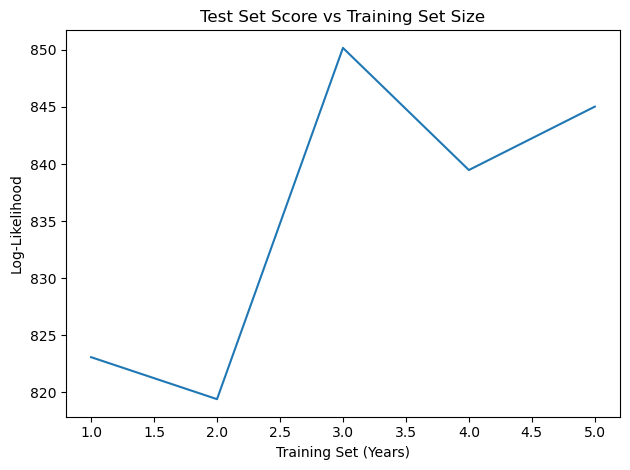

In [152]:
plt.plot(list(test_scores.keys()), list(test_scores.values()))
plt.xlabel("Training Set (Years)")
plt.ylabel("Log-Likelihood")
plt.title("Test Set Score vs Training Set Size")
plt.tight_layout()
plt.show()


VARIATION 2: DIFFERENT NUMBER OF HIDDEN STATES

In [153]:
# loop for differing number of hidden states

test_scores = {}
clean_train = train_sets[4].replace([np.inf, -np.inf], np.nan).dropna()
clean_test = test_set.replace([np.inf, -np.inf], np.nan).dropna()
train_X = clean_train.values.reshape(-1, 1)
test_X = clean_test.values.reshape(-1, 1)

for i in range(3, 8):
    loop_model = hmm.GaussianHMM(n_components=i, covariance_type="full", n_iter=10000, random_state=42)
    trained_model = loop_model.fit(train_X)
    test_set_score = trained_model.score(test_X)
    test_scores[i] = test_set_score
print(test_scores)

Model is not converging.  Current: 3896.7475268125545 is not greater than 3896.769693475009. Delta is -0.022166662454310426
Model is not converging.  Current: 3899.9738800616524 is not greater than 3899.989784334207. Delta is -0.01590427255450777


{3: 838.8971384046588, 4: 855.8578971899125, 5: 840.3503383982037, 6: 846.4467650928007, 7: 840.3558560068625}


PLOT RESULTS

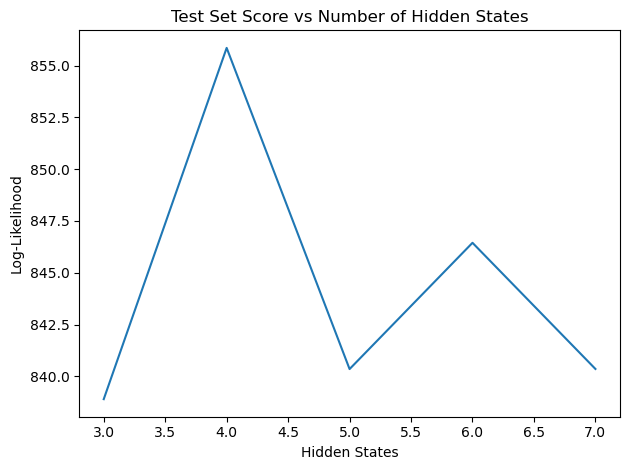

In [154]:
plt.plot(list(test_scores.keys()), list(test_scores.values()))
plt.xlabel("Hidden States")
plt.ylabel("Log-Likelihood")
plt.title("Test Set Score vs Number of Hidden States")
plt.tight_layout()
plt.show()
